In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [3]:

df = pd.read_csv("~/Desktop/House Price Prediction Dataset.csv")

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


### Check Missing Values

In [4]:
# Check all values
print(df.isna())

         Id   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  \
0     False  False     False      False   False      False     False   
1     False  False     False      False   False      False     False   
2     False  False     False      False   False      False     False   
3     False  False     False      False   False      False     False   
4     False  False     False      False   False      False     False   
...     ...    ...       ...        ...     ...        ...       ...   
1995  False  False     False      False   False      False     False   
1996  False  False     False      False   False      False     False   
1997  False  False     False      False   False      False     False   
1998  False  False     False      False   False      False     False   
1999  False  False     False      False   False      False     False   

      Condition  Garage  Price  
0         False   False  False  
1         False   False  False  
2         False   False  False  
3  

In [5]:
print(df.isna().sum())

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


### Check duplicate rows

In [6]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### No. of rows and columns

In [7]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (2000, 10) 

number of rows:  2000
number of columns:  10


### Data type of columns

In [8]:
# viewing the data types of columns
df.dtypes

Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Location'] = le.fit_transform(df['Location'])
df['Condition'] = le.fit_transform(df['Condition'])
df['Garage'] = df['Garage'].map({'Yes': 1, 'No': 0})
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df.dtypes


Id           int64
Area         int64
Bedrooms     int64
Bathrooms    int64
Floors       int64
YearBuilt    int64
Location     int64
Condition    int64
Garage       int64
Price        int64
dtype: object

### Descriptive summary Statistics

In [14]:
# Statistical summary
df.describe(include='all')

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,1.447500,1.482000,0.481000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,1.136173,1.126193,0.499764,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,0.000000,0.000000,0.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,0.000000,0.000000,0.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,1.000000,1.000000,0.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,2.000000,3.000000,1.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,3.000000,3.000000,1.000000,999656.000000


### Univariate Analysis

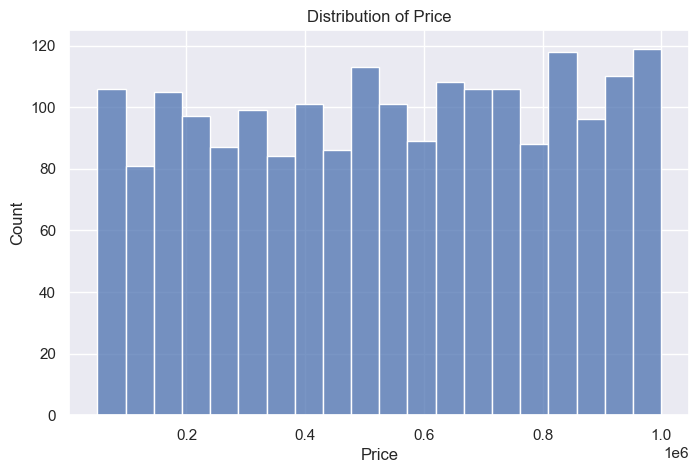

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=20)
plt.title("Distribution of Price")
plt.show()


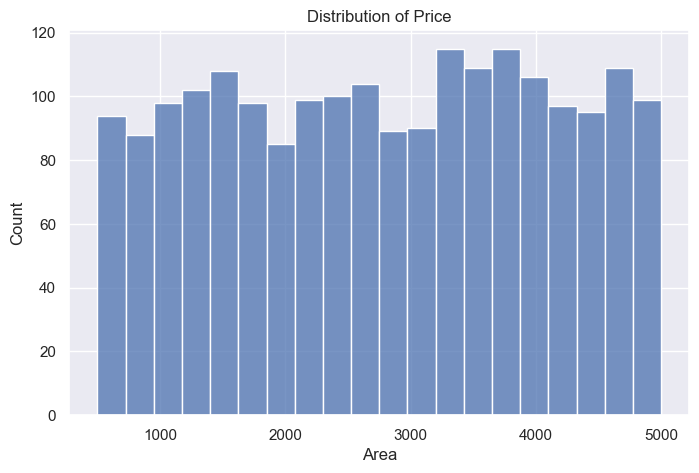

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Area'], bins=20)
plt.title("Distribution of Price")
plt.show()


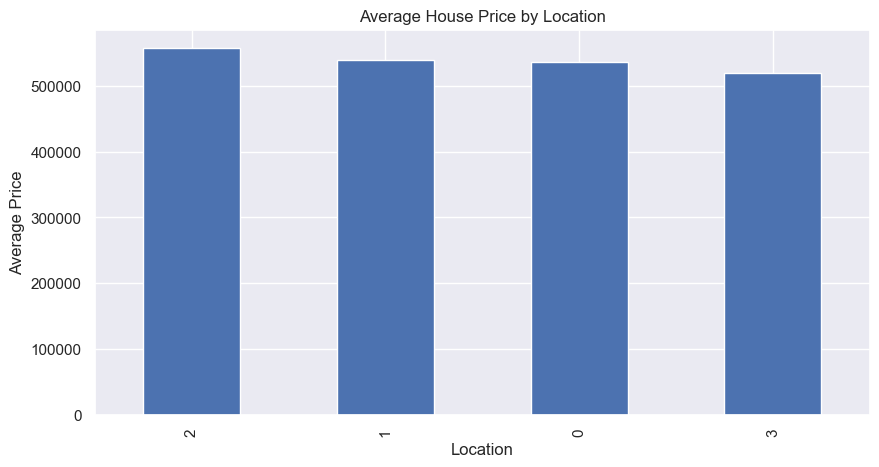

Location
2    557416.333333
1    538613.943038
0    536059.661290
3    518963.548454
Name: Price, dtype: float64

In [19]:
location_avg_price = df.groupby('Location')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
location_avg_price.plot(kind='bar')
plt.title("Average House Price by Location")
plt.ylabel("Average Price")
plt.xlabel("Location")
plt.show()

location_avg_price


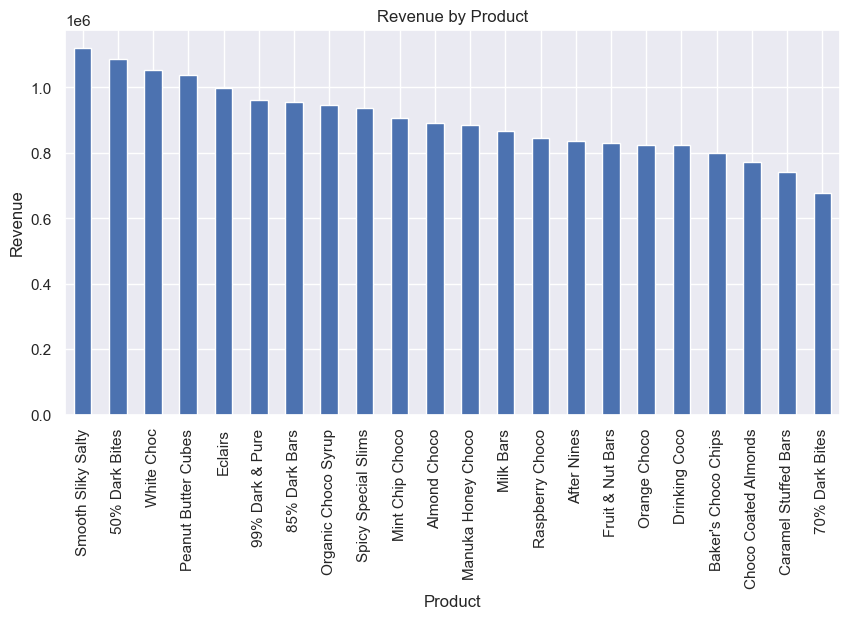

Product
Smooth Sliky Salty      1120201.09
50% Dark Bites          1087659.35
White Choc              1054257.00
Peanut Butter Cubes     1036591.09
Eclairs                  996947.96
99% Dark & Pure          960033.45
85% Dark Bars            955268.24
Organic Choco Syrup      945345.73
Spicy Special Slims      938131.69
Mint Chip Choco          904989.55
Almond Choco             890454.65
Manuka Honey Choco       885208.03
Milk Bars                866273.62
Raspberry Choco          845388.41
After Nines              837215.67
Fruit & Nut Bars         829278.96
Orange Choco             824070.85
Drinking Coco            822245.57
Baker's Choco Chips      799085.67
Choco Coated Almonds     773062.91
Caramel Stuffed Bars     742516.15
70% Dark Bites           677346.22
Name: Amount, dtype: float64

In [17]:
product_revenue = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
product_revenue.plot(kind='bar')
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.show()

product_revenue

### Revenue by Sales Person

In [20]:
top_area_price = df.groupby('Area')['Price'].sum().sort_values(ascending=False)

top_area_price.head(10)


Area
3691    2693834
4219    2669782
1213    2475048
3617    2346041
1752    2307651
3349    2222565
1516    2169133
988     2102296
1743    2043912
3274    1988015
Name: Price, dtype: int64

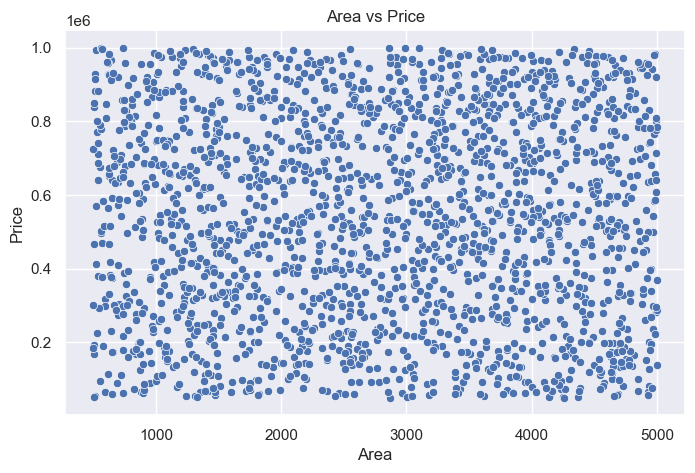

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Area', y='Price', data=df)
plt.title("Area vs Price")
plt.show()


### Correlation Matrix

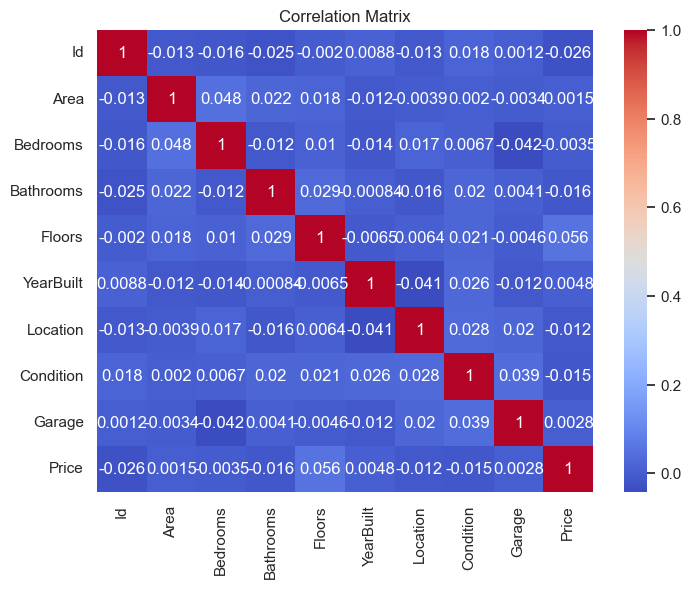

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


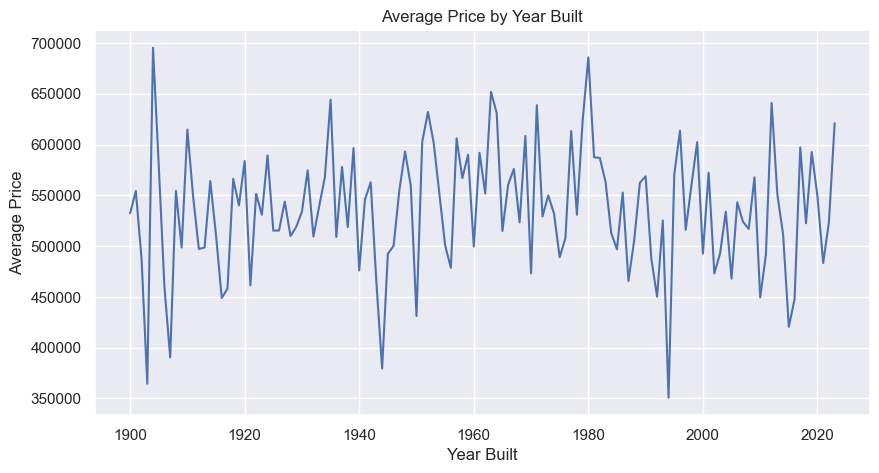

In [23]:
year_price = df.groupby('YearBuilt')['Price'].mean().sort_index()

plt.figure(figsize=(10,5))
year_price.plot()
plt.title("Average Price by Year Built")
plt.ylabel("Average Price")
plt.xlabel("Year Built")
plt.show()
